# Connect to Google Account

In [ ]:
from google.colab import drive
drive.mount('/content/data', force_remount=True)

Mounted at /content/data


# import

In [ ]:
!pip install -q catboost lightgbm xgboost

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import random
import torch

# 데이터 시각화에 사용할 라이브러리
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.inspection import permutation_importance
#from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.svm import SVC
#from lightgbm import LGBMClassifier
#from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier

#from stacking import StackingClassifier

In [ ]:
# 브라우저에서 바로 그려지도록
%matplotlib inline

# 유니코드에서  음수 부호설정
mpl.rc('axes', unicode_minus=False)

# Global Variables

In [ ]:
def reset_seeds(seed=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)      # 파이썬 환경변수 시드 고정
  np.random.seed(seed)
  torch.manual_seed(seed)                       # cpu 연산 무작위 고정
  torch.cuda.manual_seed(seed)                  # gpu 연산 무작위 고정
  torch.backends.cudnn.deterministic = True     # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


In [ ]:
import easydict
args = easydict.EasyDict()

reset_seeds() # 랜덤 고정!!

# path 정보
args.default_path = '/content/data/MyDrive/kaggle/data/'
args.train_csv = args.default_path+'train.csv'
args.test_csv = args.default_path+'test.csv'
args.default_submission_csv = args.default_path+'submission.csv'

# 제출할 파일 이름 양식 = _날짜_순
args.submission_path = '/content/data/MyDrive/kaggle/submission/'
args.submission_csv = 'submission.csv'
args.save_results = "model_results.json"

# 데이터 분석을 위한 변수들
args.random_state = 21
args.results = []

# Load Titanic


- Surived:0=사망, 1=생존
- Pclass: 1=1등석, 2=2등석, 3=3등석
- gender:male=남성, female=여성
- Age: 나이
- SibSp: 타이타닉 호에 동승한 자매/배우자의 수
- Parch: 타이타닉 호에 동승한 부모/자식의 수
- Ticket: 티켓 번호
- Fare: 승객 요금
- Cabin: 방 호수
- Embarked: 탑승지; C=셰르부르, Q=퀴즈타운, S=사우샘프턴

In [ ]:
plt.style.use('fivethirtyeight')
plt.ion()

import warnings
warnings.filterwarnings('ignore')

In [ ]:
ori_train = pd.read_csv(args.train_csv)
ori_test = pd.read_csv(args.test_csv)

# traindataset => feature+target
# test dataset => features + target은 없음 (예측해야함)
ori_train.shape, ori_test.shape

((916, 12), (393, 11))

In [ ]:
pd.read_csv(args.default_submission_csv).shape

(393, 2)

In [ ]:
ori_train.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [ ]:
ori_train['passengerid'].nunique(), ori_train.shape[0]

(916, 916)

In [ ]:
ori_train.drop('passengerid', axis=1, inplace=True)
ori_train.head()

,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


In [ ]:
ori_test.set_index(['passengerid'], inplace=True)
print(f'{ori_test.shape}')

(393, 10)


,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
passengerid,,,,,,,,,,
916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# train_test_split

In [ ]:
new_survived = pd.Categorical(ori_train["survived"])
new_survived = new_survived.rename_categories(["Died","Survived"])

new_survived.describe()

,counts,freqs
categories,,
Died,570,0.622271
Survived,346,0.377729


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y = ori_train['survived']
X = ori_train.drop(['survived'], axis=1)

In [ ]:
reset_seeds()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=ori_train['survived'])
# 테스트 사이즈 축소

X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((641, 10), (275, 10), (641,), (275,))

# Data Preprocessing

In [ ]:
train = X_tr.copy()       # 학습용 데이터셋 (features+target)
test = X_te.copy()        # 평가용 데이터셋 (features+target)
ori_te = ori_test.copy()  # 제출용 데이터셋 (features)

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------------
# 1. train 기준 전처리 규칙 학습
# -----------------------------------
def fit_preprocess_rules(train: pd.DataFrame) -> dict:
    train = train.copy()

    # 기본 name 파생
    train["family_name"] = train["name"].str.split(",").str[0].str.strip()
    train["title"] = train["name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()

    train["title"] = train["title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    rare_title_map = {
        "Lady": "Noble",
        "Countess": "Noble",
        "Sir": "Noble",
        "Dona": "Noble",
        "Don": "Noble",
        "Jonkheer": "Noble",
        "Capt": "Officer",
        "Col": "Officer",
        "Major": "Officer",
        "Dr": "Professional",
        "Rev": "Professional"
    }

    train["title_group"] = train["title"].replace(rare_title_map)

    # age 규칙
    family_age_median = train.groupby("family_name")["age"].median().to_dict()
    family_count = train.groupby("family_name")["family_name"].count().to_dict()
    pg_age_median = train.groupby(["pclass", "gender"])["age"].median().to_dict()
    global_age_median = train["age"].median()

    # fare 규칙
    fare_median = train["fare"].median()
    train_fare_filled = train["fare"].fillna(fare_median)

    _, fare_bins = pd.qcut(
        train_fare_filled,
        q=4,
        labels=["low", "mid", "high", "very_high"],
        retbins=True,
        duplicates="drop"
    )

    fare_bins = np.array(fare_bins, dtype=float)
    fare_bins[0] = -np.inf
    fare_bins[-1] = np.inf

    rules = {
        "rare_title_map": rare_title_map,
        "family_age_median": family_age_median,
        "family_count": family_count,
        "pg_age_median": pg_age_median,
        "global_age_median": global_age_median,
        "fare_median": fare_median,
        "fare_bins": fare_bins,
        "fare_labels": ["low", "mid", "high", "very_high"]
    }

    return rules


# -----------------------------------
# 2. age 채우기 함수
# -----------------------------------
def fill_age(row, rules):
    if pd.notnull(row["age"]):
        return row["age"]

    fam = row["family_name"]

    # 1) family_name 기준
    if rules["family_count"].get(fam, 0) >= 2:
        fam_med = rules["family_age_median"].get(fam, np.nan)
        if pd.notnull(fam_med):
            return fam_med

    # 2) pclass + gender 기준
    key = (row["pclass"], row["gender"])
    pg_med = rules["pg_age_median"].get(key, np.nan)
    if pd.notnull(pg_med):
        return pg_med

    # 3) 전체 median
    return rules["global_age_median"]


# -----------------------------------
# 3. feature 생성
# -----------------------------------
def add_hypothesis_features(df: pd.DataFrame, rules: dict) -> pd.DataFrame:
    df = df.copy()

    rare_title_map = rules["rare_title_map"]
    fare_median = rules["fare_median"]
    fare_bins = rules["fare_bins"]
    fare_labels = rules["fare_labels"]

    # 1. 기본 name 파생
    df["family_name"] = df["name"].str.split(",").str[0].str.strip()
    df["title"] = df["name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()

    df["title"] = df["title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    df["title_group"] = df["title"].replace(rare_title_map)

    # 2. 가족 관련
    df["family_size"] = df["sibsp"] + df["parch"] + 1
    df["is_alone"] = (df["family_size"] == 1).astype(int)

    def family_size_group(x):
        if x == 1:
            return "alone"
        elif 2 <= x <= 4:
            return "small"
        else:
            return "large"

    df["family_size_group"] = df["family_size"].apply(family_size_group)

    # 3. age 결측치 처리
    df["age"] = df.apply(lambda r: fill_age(r, rules), axis=1)

    # 4. 성별 관련
    df["is_female"] = (df["gender"] == "female").astype(int)
    df["is_male"] = (df["gender"] == "male").astype(int)

    # 5. 선상 접근성 / 위치 근사

    df["deck"] = df["cabin"].fillna("Unknown").astype(str).apply(
    lambda x: x[0] if x != "Unknown" else "Unknown")
    df["deck"] = df["cabin"].str[0]


    df["has_cabin"] = df["cabin"].notnull().astype(int)

    df["upper_access"] = 0
    df.loc[df["pclass"] == 1, "upper_access"] = 2
    df.loc[df["pclass"] == 2, "upper_access"] = 1
    df.loc[df["pclass"] == 3, "upper_access"] = 0

    df["access_score"] = df["upper_access"] + df["has_cabin"]

    # 6. age / fare 구간화
    df["age_bin"] = pd.cut(
        df["age"],
        bins=[0,5,10,15,20,25, 30,35,40,45, 50,55,60,65,70,75,80,85,90],
        labels=False,
        include_lowest=True
    )

    df["fare"] = df["fare"].fillna(fare_median)

    df["fare_bin"] = pd.cut(
        df["fare"],
        bins=fare_bins,
        labels=fare_labels,
        include_lowest=True
    )

    def family_survival_zone(size):
        if size == 1:
            return "alone"
        elif 2 <= size <= 4:
            return "small"
        elif 5 <= size <= 7:
            return "medium"
        else:
            return "large"


    # 7. 조합 feature 0311
    df["is_child"] = (df["age"] < 16).astype(int)
    df["male_child"] = ((df["gender"] == "male") & (df["age"] < 16)).astype(int)
    df["female_child"] = ((df["gender"] == "female") & (df["age"] < 16)).astype(int)
    df["pclass_gender_has_cabin"] = ((df["is_female"] == 1) & (df["has_cabin"] == 0) & (df["pclass"] == 3)).astype(int) #0311
    df["child_with_family"] = ((df["age"] < 16) & (df["family_size"] > 1)).astype(int)
    df["fare_per_person"] = (df["fare"] / np.maximum(df["family_size"], 1)).astype(float)

    #######################################################################
    df["pclass_gender"] = df["pclass"].astype(str) + "_" + df["gender"].astype(str)            #0313
    df["pclass_title"] = df["pclass"].astype(str) + "_" + df["title_group"].astype(str)
    df["pclass_age_bin"] = df["pclass"].astype(str) + "_" + df["age_bin"].astype(str)
    df["pclass_is_male"] = df["pclass"].astype(str) + "_" + df["is_male"].astype(str)
    df["pclass_is_alone"] = df["pclass"].astype(str) + "_" + df["is_alone"].astype(str)
    df["access_pclass"] = df["access_score"].astype(str) + "_" + df["pclass"].astype(str)
    df["gender_title_group"] = df["gender"].astype(str) + "_" + df["title_group"].astype(str)        #0313
    df["gender_age_bin"] = df["gender"].astype(str) + "_" + df["age_bin"].astype(str)                #0313
    df["has_cabin_gender"] = df["has_cabin"].astype(str) + "_" + df["gender"].astype(str)                       #0311
    #df["ticket_farebin"] = df["ticket"].astype(str) + "_" + df["fare_bin"].astype(str)                          #0311
    df["family_survival_zone"] = df["family_size"].apply(family_survival_zone)
    df["female_child_pclass"] = df["female_child"].astype(str) + "_" + df["pclass"].astype(str)
    df["female_age_bin"] = df["is_female"].astype(str) + "_" + df["age_bin"].astype(str)
    df["female_familysize"] = df["is_female"].astype(str) + "_" + df["family_size"].astype(str)                #실험1
    df["male_familysize"] = df["is_male"].astype(str) + "_" + df["family_size"].astype(str)                    #실험1
    df["pclass_farebin"] = df["pclass"].astype(str) + "_" + df["fare_bin"].astype(str)
    #df["ticket_farebin_gender"] = df["gender"].astype(str) + "_" + df["ticket_farebin"].astype(str)
    df["gender_farebin"] =  df["gender"].astype(str) + "_" + df["fare_bin"].astype(str)
    #df["cabin_fare_bin"] = df["cabin"].astype(str) + "_" + df["fare_bin"].astype(str)                          #실험1
    #df["cabin_fare_bin_family_size"] = df["cabin_fare_bin"].astype(str) + "_" + df["family_size"].astype(str)
    #df["fare_bin_familysize"] = df["fare_bin"].astype(str) + "_" + df["family_size"].astype(str)
    df["pclass_gender_has_cabin"] = df["pclass_gender"].astype(str) + "_" + df["has_cabin"].astype(str)        #0311

    ####################################################################

    #df["surname"] = df["name"].str.split(",").str[0]
    #surname_survival = df.groupby("surname")["survived"].mean()
    #df["surname_survival_rate"] = df["surname"].map(surname_survival)


    ticket_counts = df.groupby("ticket")["ticket"].transform("count")

    df["ticket_group_size"] = ticket_counts

    df["ticket_group_size_bin"] = pd.cut(
        df["ticket_group_size"],
        bins=[0,1,2,4,10],
        labels=["solo","pair","small","large"]
    )

    ticket_count = df["ticket"].value_counts()

    df["ticket_group"] = df["ticket"].map(ticket_count)
    df["ticket_group"] = df["ticket_group"].apply(lambda x: 1 if x == 1 else 0)

    df["ticket_group_farebin"] = df["ticket_group"].astype(str) + "_" + df["fare_bin"].astype(str)


    return df

# EDA 분석 피쳐보기

In [ ]:
# 1. train 기준 규칙 생성
rules = fit_preprocess_rules(train)

# 2. train / test / ori_te 모두 같은 규칙 적용
train = add_hypothesis_features(train, rules)
test = add_hypothesis_features(test, rules)
ori_te = add_hypothesis_features(ori_te, rules)

# 3. 확인
train.isnull().sum().sum(), test.isnull().sum().sum(), ori_te.isnull().sum().sum(),

(np.int64(1006), np.int64(431), np.int64(593))

In [ ]:
train.shape

(641, 50)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 641 entries, 539 to 636
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   pclass                   641 non-null    int64   
 1   name                     641 non-null    object  
 2   gender                   641 non-null    object  
 3   age                      641 non-null    float64 
 4   sibsp                    641 non-null    int64   
 5   parch                    641 non-null    int64   
 6   ticket                   641 non-null    object  
 7   fare                     641 non-null    float64 
 8   cabin                    138 non-null    object  
 9   embarked                 641 non-null    object  
 10  family_name              641 non-null    object  
 11  title                    641 non-null    object  
 12  title_group              641 non-null    object  
 13  family_size              641 non-null    int64   
 14  is_alone     

In [ ]:
drop_cols = ["name", "ticket", "cabin", "family_name", "is_male"]
#  is_male , upper_access, access_pclass, child_with_family, family_survival_zone
train = train.drop(columns=[c for c in drop_cols if c in train.columns])
test = test.drop(columns=[c for c in drop_cols if c in test.columns])
ori_te = ori_te.drop(columns=[c for c in drop_cols if c in ori_te.columns])

# 컬럼 정의 함수

In [ ]:
def get_feature_groups(df: pd.DataFrame):
    numeric_cols = [
        "age", "sibsp", "parch", "fare", "family_size",
        "is_alone", "is_female",  "has_cabin",
        "upper_access", "access_score", "is_child",
        "male_child", "female_child", "child_with_family",
        "fare_per_person", "ticket_group"
    ]
    # "is_male",

    categorical_cols = [
        "pclass", "gender", "embarked", "title", "title_group",
        "family_size_group", "deck", "age_bin", "fare_bin",
        "pclass_gender_has_cabin", "pclass_gender", "pclass_title",
        "pclass_age_bin", "pclass_is_male", "pclass_is_alone",
        "access_pclass", "gender_title_group", "gender_age_bin",
        "has_cabin_gender", "family_survival_zone",
        "female_child_pclass", "female_age_bin", "female_familysize",
        "male_familysize", "pclass_farebin", "gender_farebin",
        "ticket_group_size", "ticket_group_size_bin",
        "ticket_group_farebin"
    ]

    numeric_cols = [c for c in numeric_cols if c in df.columns]
    categorical_cols = [c for c in categorical_cols if c in df.columns]

    return numeric_cols, categorical_cols

# 데이터프레임 정리

In [ ]:
def prepare_frame(df: pd.DataFrame, numeric_cols: list, categorical_cols: list):
    df = df.copy()

    if "deck" in df.columns:
        df["deck"] = df["deck"].astype("object").fillna("Unknown")

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("object").fillna("Unknown").astype(str)

    for col in numeric_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    return df

# 데이터 정리 함수

In [ ]:
def get_feature_groups(df: pd.DataFrame):
    feature_cols = [
        "pclass",
        "age",
        "fare",
        "embarked",
        "title",
        "title_group",
        "family_size",
        "is_female",
        "deck",
        "upper_access",
        "access_score",
        "age_bin",
        "fare_per_person",
        "family_survival_zone",
        "ticket_group_size"
    ]

    cat_cols = [
        "embarked",
        "title",
        "title_group",
        "deck",
        "family_survival_zone"
    ]

    num_cols = [c for c in feature_cols if c not in cat_cols]

    return numeric_cols, cat_cols

# 전처리기 생성 함수

In [ ]:
def build_preprocessor(numeric_cols: list, categorical_cols: list):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop"
    )
    return preprocessor

In [ ]:
train.shape, test.shape, ori_te.shape

((641, 45), (275, 45), (393, 45))

# Training

In [ ]:
reset_seeds()

# 모델 생성 함수

In [ ]:
def get_base_models():
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.0,
        reg_alpha=0.3,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    lgb_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )

    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_state=42
    )

    return xgb_model, lgb_model, cat_model


def get_meta_model():
    return LogisticRegression(
        max_iter=3000,
        random_state=42
    )

# threshold 탐색 함수

In [ ]:
def find_best_threshold(y_true, pred_proba):
    best_th = 0.5
    best_f1 = -1

    for th in np.arange(0.35, 0.66, 0.01):
        pred = (pred_proba >= th).astype(int)
        score = f1_score(y_true, pred)

        if score > best_f1:
            best_f1 = score
            best_th = th

    return best_th, best_f1

# 평가 지표 함수

In [ ]:
def evaluate_predictions(y_true, probas, threshold=0.5):
    pred = (probas >= threshold).astype(int)

    return {
        "threshold": threshold,
        "f1": f1_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "accuracy": accuracy_score(y_true, pred),
        "auc": roc_auc_score(y_true, probas)
    }

# Base model OOF 생성 함수

In [ ]:
def generate_oof_predictions(X, y, X_test, cat_cols, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_xgb = np.zeros(len(X))
    oof_lgb = np.zeros(len(X))
    oof_cat = np.zeros(len(X))

    test_xgb = np.zeros(len(X_test))
    test_lgb = np.zeros(len(X_test))
    test_cat = np.zeros(len(X_test))

    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X.iloc[tr_idx].copy()
        X_va = X.iloc[va_idx].copy()
        y_tr_fold = y.iloc[tr_idx].copy()
        y_va_fold = y.iloc[va_idx].copy()

        xgb_model, lgb_model, cat_model = get_base_models()

        # XGB
        X_tr_xgb, X_va_xgb, X_te_xgb = encode_for_xgb(X_tr, X_va, X_test, cat_cols)
        xgb_model.fit(X_tr_xgb, y_tr_fold)
        va_pred_xgb = xgb_model.predict_proba(X_va_xgb)[:, 1]
        te_pred_xgb = xgb_model.predict_proba(X_te_xgb)[:, 1]
        oof_xgb[va_idx] = va_pred_xgb
        test_xgb += te_pred_xgb / n_splits

        # LGB
        X_tr_lgb, X_va_lgb, X_te_lgb = encode_for_lgb(X_tr, X_va, X_test, cat_cols)
        lgb_model.fit(X_tr_lgb, y_tr_fold)
        va_pred_lgb = lgb_model.predict_proba(X_va_lgb)[:, 1]
        te_pred_lgb = lgb_model.predict_proba(X_te_lgb)[:, 1]
        oof_lgb[va_idx] = va_pred_lgb
        test_lgb += te_pred_lgb / n_splits

        # CAT
        X_tr_cat, X_va_cat, X_te_cat = encode_for_cat(X_tr, X_va, X_test, cat_cols)
        cat_features_idx = [X_tr_cat.columns.get_loc(c) for c in cat_cols]
        cat_model.fit(
            X_tr_cat,
            y_tr_fold,
            cat_features=cat_features_idx
        )
        va_pred_cat = cat_model.predict_proba(X_va_cat)[:, 1]
        te_pred_cat = cat_model.predict_proba(X_te_cat)[:, 1]
        oof_cat[va_idx] = va_pred_cat
        test_cat += te_pred_cat / n_splits

        fold_auc = {
            "fold": fold,
            "xgb_auc": roc_auc_score(y_va_fold, va_pred_xgb),
            "lgb_auc": roc_auc_score(y_va_fold, va_pred_lgb),
            "cat_auc": roc_auc_score(y_va_fold, va_pred_cat),
        }
        fold_scores.append(fold_auc)

        print(
            f"[Fold {fold}] "
            f"XGB AUC={fold_auc['xgb_auc']:.5f} | "
            f"LGB AUC={fold_auc['lgb_auc']:.5f} | "
            f"CAT AUC={fold_auc['cat_auc']:.5f}"
        )

    oof_dict = {
        "xgb": oof_xgb,
        "lgb": oof_lgb,
        "cat": oof_cat
    }

    test_dict = {
        "xgb": test_xgb,
        "lgb": test_lgb,
        "cat": test_cat
    }

    fold_scores_df = pd.DataFrame(fold_scores)
    return oof_dict, test_dict, fold_scores_df

# OOF 예측 생성 실험

In [ ]:
oof_dict, test_dict, fold_scores_df = generate_oof_predictions(
    X=X,
    y=y,
    X_test=X_test,
    cat_cols=cat_cols,
    n_splits=5,
    random_state=42
)

fold_scores_df

# Base model 요약 함수

In [ ]:
def summarize_base_models(y, oof_base, fold_metrics):
    rows = []

    for name, probas in oof_base.items():
        best_th, _ = find_best_threshold(y, probas, metric="f1")
        result = evaluate_predictions(y, probas, threshold=best_th)

        rows.append({
            "model": name,
            "best_threshold": best_th,
            "f1": result["f1"],
            "precision": result["precision"],
            "recall": result["recall"],
            "accuracy": result["accuracy"],
            "auc": result["auc"],
            "cv_mean_fold_f1@0.5": np.mean(fold_metrics[name]["f1"]),
            "cv_std_fold_f1@0.5": np.std(fold_metrics[name]["f1"]),
            "cv_mean_fold_auc": np.mean(fold_metrics[name]["auc"]),
            "cv_std_fold_auc": np.std(fold_metrics[name]["auc"]),
        })

    summary_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
    return summary_df


# Meta 입력 생성 함수

In [ ]:
def build_meta_features(oof_base, test_base):
    meta_X = pd.DataFrame({
        name: oof_base[name] for name in oof_base.keys()
    })

    meta_test = pd.DataFrame({
        name: test_base[name] for name in test_base.keys()
    })

    return meta_X, meta_test

# Meta OOF 생성 함수

In [ ]:
def generate_meta_oof_predictions(meta_X, y, meta_test, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    meta_oof = np.zeros(len(meta_X))
    meta_test_proba = np.zeros(len(meta_test))

    meta_fold_f1 = []
    meta_fold_auc = []

    last_meta_model = None
    last_meta_valid_X = None
    last_meta_valid_y = None
    last_meta_valid_proba = None

    for fold, (tr_idx, val_idx) in enumerate(skf.split(meta_X, y), 1):
        X_meta_train = meta_X.iloc[tr_idx].copy()
        X_meta_valid = meta_X.iloc[val_idx].copy()
        y_meta_train = y.iloc[tr_idx].copy()
        y_meta_valid = y.iloc[val_idx].copy()

        meta_model = get_meta_model()
        meta_model.fit(X_meta_train, y_meta_train)

        valid_meta_proba = meta_model.predict_proba(X_meta_valid)[:, 1]
        test_meta_proba = meta_model.predict_proba(meta_test)[:, 1]

        meta_oof[val_idx] = valid_meta_proba
        meta_test_proba += test_meta_proba / n_splits

        pred_05 = (valid_meta_proba >= 0.5).astype(int)
        fold_f1 = f1_score(y_meta_valid, pred_05)
        fold_auc = roc_auc_score(y_meta_valid, valid_meta_proba)

        meta_fold_f1.append(fold_f1)
        meta_fold_auc.append(fold_auc)

        print(f"\n[Meta Fold {fold}] F1: {fold_f1:.5f} | AUC: {fold_auc:.5f}")

        last_meta_model = meta_model
        last_meta_valid_X = X_meta_valid
        last_meta_valid_y = y_meta_valid
        last_meta_valid_proba = valid_meta_proba

    return {
        "meta_oof": meta_oof,
        "meta_test_proba": meta_test_proba,
        "meta_fold_f1": meta_fold_f1,
        "meta_fold_auc": meta_fold_auc,
        "last_meta_model": last_meta_model,
        "last_meta_valid_X": last_meta_valid_X,
        "last_meta_valid_y": last_meta_valid_y,
        "last_meta_valid_proba": last_meta_valid_proba
    }

# Meta 요약 함수

In [ ]:
def summarize_meta_model(y, meta_oof, meta_fold_f1, meta_fold_auc):
    best_th, _ = find_best_threshold(y, meta_oof, metric="f1")
    result = evaluate_predictions(y, meta_oof, threshold=best_th)

    summary = pd.DataFrame([{
        "model": "stacking_meta_lr",
        "best_threshold": best_th,
        "f1": result["f1"],
        "precision": result["precision"],
        "recall": result["recall"],
        "accuracy": result["accuracy"],
        "auc": result["auc"],
        "cv_mean_fold_f1@0.5": np.mean(meta_fold_f1),
        "cv_std_fold_f1@0.5": np.std(meta_fold_f1),
        "cv_mean_fold_auc": np.mean(meta_fold_auc),
        "cv_std_fold_auc": np.std(meta_fold_auc),
    }])

    return summary, best_th, result

# confusion matrix 함수


In [ ]:
def plot_confusion_matrix_figure(y_true, probas, threshold, save_path=None):
    pred = (probas >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix (th={threshold})")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# ROC curve 함수

In [ ]:
def plot_roc_curve_figure(y_true, probas, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, probas)
    auc_score = roc_auc_score(y_true, probas)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# 모델별 AUC 비교 그래프 함수

In [ ]:
def plot_model_auc_comparison(y_true, model_proba_dict, save_path=None):
    rows = []
    for name, probas in model_proba_dict.items():
        auc_score = roc_auc_score(y_true, probas)
        rows.append({"model": name, "auc": auc_score})

    auc_df = pd.DataFrame(rows).sort_values("auc", ascending=False)

    plt.figure(figsize=(7, 4))
    plt.bar(auc_df["model"], auc_df["auc"])
    plt.ylabel("AUC")
    plt.title("Model AUC Comparison")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return auc_df

# feature importance 함수(LGBM 직접 / 나머지 permutation)

In [ ]:
def get_model_feature_importance(
    model,
    X_valid_enc,
    y_valid,
    feature_names,
    model_name="model",
    n_repeats=5
):
    # 1) tree 계열 / boosting 계열: feature_importances_
    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False).reset_index(drop=True)
        return imp

    # 2) 선형 모델: coef_
    if hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim > 1:
            coef = coef[0]

        imp = pd.DataFrame({
            "feature": feature_names,
            "importance": np.abs(coef)
        }).sort_values("importance", ascending=False).reset_index(drop=True)
        return imp

    # 3) 그 외 모델: permutation importance
    perm = permutation_importance(
        model,
        X_valid_enc,
        y_valid,
        scoring="f1",
        n_repeats=n_repeats,
        random_state=42
    )

    imp = pd.DataFrame({
        "feature": feature_names,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return imp


def plot_feature_importance_heatmap(importance_df, top_n=20, title="Feature Importance Heatmap", save_path=None):
    plot_df = importance_df.head(top_n).copy()
    plot_df = plot_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, max(6, top_n * 0.35)))
    plt.imshow(plot_df[["importance"]], aspect="auto")
    plt.yticks(range(len(plot_df)), plot_df["feature"])
    plt.xticks([0], ["importance"])
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [ ]:
def get_logistic_coef_table(model, feature_names):
    coef = model.coef_
    if coef.ndim > 1:
        coef = coef[0]

    df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return df

# FP/FN 분석 함수

In [ ]:
def analyze_fp_fn(X_valid, y_true, probas, threshold, save_dir=None, prefix="meta"):
    pred = (probas >= threshold).astype(int)

    error_df = X_valid.copy()
    error_df["y_true"] = y_true.values if isinstance(y_true, pd.Series) else y_true
    error_df["y_pred"] = pred
    error_df["y_proba"] = probas

    fp_df = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)].copy()
    fn_df = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)].copy()

    print(f"\n[FP/FN Analysis - {prefix}]")
    print("FP count:", len(fp_df))
    print("FN count:", len(fn_df))

    if save_dir:
        fp_df.to_csv(os.path.join(save_dir, f"{prefix}_fp_cases.csv"), index=False)
        fn_df.to_csv(os.path.join(save_dir, f"{prefix}_fn_cases.csv"), index=False)

    return fp_df, fn_df

# 숫자형 상관관계 heatmap 함수

In [ ]:
def plot_numeric_correlation_heatmap(X, save_path=None):
    numeric_df = X.select_dtypes(include=["int64", "float64"]).copy()

    corr = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
    plt.title("Numeric Feature Correlation Heatmap")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return corr

# 전체 피처 상관관계 heatmap 함수

In [ ]:
def plot_all_feature_correlation_heatmap(X, save_path=None):
    X_corr = X.copy()

    for col in X_corr.columns:
        if X_corr[col].dtype == "object":
            X_corr[col] = X_corr[col].astype("category").cat.codes

    corr = X_corr.corr(numeric_only=False)

    plt.figure(figsize=(18, 14))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
    plt.title("All Feature Correlation Heatmap")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return corr

# 모델 상관 관계 분석

In [ ]:
def analyze_base_model_relationship(oof_base, y_true=None, threshold=0.5):
    """
    base 모델들의 관계 분석
    """

    pred_df = pd.DataFrame(oof_base)

    print("="*80)
    print("1️⃣ OOF 예측 확률 상관계수")
    corr_df = pred_df.corr()
    print(corr_df.round(4))

    print("\n"+"="*80)
    print("2️⃣ 예측 확률 통계")
    print(pred_df.describe().T.round(4))

    print("\n"+"="*80)
    print("3️⃣ 모델 예측 불일치율 (diversity)")

    bin_df = (pred_df >= threshold).astype(int)

    rows = []
    models = list(bin_df.columns)

    for i in range(len(models)):
        for j in range(i+1, len(models)):
            m1 = models[i]
            m2 = models[j]

            disagree = (bin_df[m1] != bin_df[m2]).mean()

            rows.append({
                "model_a": m1,
                "model_b": m2,
                "disagree_rate": disagree
            })

    disagree_df = pd.DataFrame(rows).sort_values("disagree_rate", ascending=False)
    print(disagree_df.round(4))


    if y_true is not None:

        print("\n"+"="*80)
        print("4️⃣ 모델 오답 겹침 비율")

        rows = []
        y_true = np.asarray(y_true)

        for i in range(len(models)):
            for j in range(i+1, len(models)):
                m1 = models[i]
                m2 = models[j]

                wrong1 = (bin_df[m1].values != y_true)
                wrong2 = (bin_df[m2].values != y_true)

                overlap = (wrong1 & wrong2).mean()

                rows.append({
                    "model_a": m1,
                    "model_b": m2,
                    "wrong_overlap_rate": overlap
                })

        overlap_df = pd.DataFrame(rows).sort_values("wrong_overlap_rate", ascending=False)
        print(overlap_df.round(4))


    return corr_df

# 결과 저장 함수

In [ ]:
def save_result_tables(final_eval_df, auc_df, meta_oof, meta_test_proba, final_test_pred, y, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    final_eval_df.to_csv(os.path.join(save_dir, "stacking_f1_evaluation.csv"), index=False)
    auc_df.to_csv(os.path.join(save_dir, "model_auc_comparison.csv"), index=False)

    oof_df = pd.DataFrame({
        "y_true": y.values,
        "meta_oof": meta_oof
    })
    oof_df.to_csv(os.path.join(save_dir, "meta_oof_predictions.csv"), index=False)

    test_pred_df = pd.DataFrame({
        "meta_test_proba": meta_test_proba,
        "meta_test_pred": final_test_pred
    })
    test_pred_df.to_csv(os.path.join(save_dir, "meta_test_predictions.csv"), index=False)

    submission = pd.DataFrame({
        "passengerid": ori_te.index,      # 테스트 데이터 인덱스
        "survived": final_test_pred
    })

    submission.to_csv(
        os.path.join(save_dir, "submission_te1.csv"),
        index=False
    )

    print("submission saved :", os.path.join(save_dir, "submission.csv"))

# 실행 함수

In [ ]:
def run_stacking_full_pipeline(train_df, y, test_df, save_dir="results_stacking"):
    os.makedirs(save_dir, exist_ok=True)

    # 1) 컬럼 구분
    numeric_cols, categorical_cols = get_feature_groups(train_df)

    # 2) 데이터 준비
    X = prepare_frame(train_df, numeric_cols, categorical_cols)
    X_test = prepare_frame(test_df, numeric_cols, categorical_cols)

    # 3) 전처리기
    preprocessor = build_preprocessor(numeric_cols, categorical_cols)

    # 4) Base OOF
    base_result = generate_base_oof_predictions(
        X=X,
        y=y,
        X_test=X_test,
        preprocessor=preprocessor,
        n_splits=5,
        random_state=42
    )

    # 5) Base 요약
    base_summary_df = summarize_base_models(
        y=y,
        oof_base=base_result["oof_base"],
        fold_metrics=base_result["fold_metrics"]
    )

    print("\n" + "=" * 80)
    print("[Base Model Summary]")
    print(base_summary_df.round(6))

    # 6) Meta 입력
    meta_X, meta_test = build_meta_features(
        oof_base=base_result["oof_base"],
        test_base=base_result["test_base"]
    )

    # 7) Meta OOF
    meta_result = generate_meta_oof_predictions(
        meta_X=meta_X,
        y=y,
        meta_test=meta_test,
        n_splits=5,
        random_state=42
    )

    # 8) Meta 요약
    meta_summary_df, best_meta_th, meta_eval = summarize_meta_model(
        y=y,
        meta_oof=meta_result["meta_oof"],
        meta_fold_f1=meta_result["meta_fold_f1"],
        meta_fold_auc=meta_result["meta_fold_auc"]
    )

    print("\n" + "=" * 80)
    print("[Meta Model Summary]")
    print(meta_summary_df.round(6))
    print(f"\nBest Meta Threshold: {best_meta_th}")
    print(json.dumps(meta_eval, indent=2))

    # 9) 최종 평가표
    final_eval_df = pd.concat([base_summary_df, meta_summary_df], ignore_index=True)
    final_eval_df = final_eval_df.sort_values("f1", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("[Final Evaluation Table]")
    print(final_eval_df.round(6))

    # 10) 최종 test pred
    final_test_pred = (meta_result["meta_test_proba"] >= best_meta_th).astype(int)

    # 11) confusion matrix / roc
    plot_confusion_matrix_figure(
        y_true=y,
        probas=meta_result["meta_oof"],
        threshold=best_meta_th,
        save_path=os.path.join(save_dir, "meta_confusion_matrix.png")
    )

    plot_roc_curve_figure(
        y_true=y,
        probas=meta_result["meta_oof"],
        save_path=os.path.join(save_dir, "meta_roc_curve.png")
    )

    # 12) 모델별 AUC 비교
    model_proba_dict = {
        "cat": base_result["oof_base"]["cat"],
        "svc": base_result["oof_base"]["svc"],
        "lr": base_result["oof_base"]["lr"],
        "meta": meta_result["meta_oof"]
    }

    auc_df = plot_model_auc_comparison(
        y_true=y,
        model_proba_dict=model_proba_dict,
        save_path=os.path.join(save_dir, "model_auc_comparison.png")
    )

    print("\n[Model AUC Table]")
    print(auc_df.round(6))

    # 13) feature importance -
    cat_imp = get_model_feature_importance(
        model=base_result["last_models"]["cat"],
        X_valid_enc=base_result["last_X_valid_enc"],
        y_valid=base_result["last_y_valid"],
        feature_names=base_result["last_feature_names"],
        model_name="cat"
    )

    svc_imp = get_model_feature_importance(
        model=base_result["last_models"]["svc"],
        X_valid_enc=base_result["last_X_valid_enc"],
        y_valid=base_result["last_y_valid"],
        feature_names=base_result["last_feature_names"],
        model_name="svc"
    )

    lr_imp = get_model_feature_importance(
        model=base_result["last_models"]["lr"],
        X_valid_enc=base_result["last_X_valid_enc"],
        y_valid=base_result["last_y_valid"],
        feature_names=base_result["last_feature_names"],
        model_name="lr"
    )

    # 각 모델의 중요성 시각화 히트맵
    plot_feature_importance_heatmap(cat_imp, top_n=20, title="cat_imp Feature Importance")
    plot_feature_importance_heatmap(svc_imp, top_n=20, title="svc_imp Feature Importance")
    plot_feature_importance_heatmap(lr_imp, top_n=20, title="lr_imp Feature Importance")

    cat_imp.to_csv(os.path.join(save_dir, "cat_imp_feature_importance.csv"), index=False)
    svc_imp.to_csv(os.path.join(save_dir, "svc_imp_feature_importance.csv"), index=False)
    lr_imp.to_csv(os.path.join(save_dir, "lr_imp_feature_importance.csv"), index=False)

    # 14) FP / FN 분석
    fp_df, fn_df = analyze_fp_fn(
        X_valid=X,
        y_true=y,
        probas=meta_result["meta_oof"],
        threshold=best_meta_th,
        save_dir=save_dir,
        prefix="meta"
    )

    # 15) 상관관계 heatmap
    numeric_corr = plot_numeric_correlation_heatmap(
        X,
        save_path=os.path.join(save_dir, "numeric_corr_heatmap.png")
    )

    all_corr = plot_all_feature_correlation_heatmap(
        X,
        save_path=os.path.join(save_dir, "all_feature_corr_heatmap.png")
    )

    numeric_corr.to_csv(os.path.join(save_dir, "numeric_corr_matrix.csv"))
    all_corr.to_csv(os.path.join(save_dir, "all_feature_corr_matrix.csv"))

    # 16) 모델 관계 분석
    corr_df = analyze_base_model_relationship(
        base_result["oof_base"],
        y_true=y
    )
    corr_df.to_csv(os.path.join(save_dir, "model_relationship_analysis.csv"))

    # 17) 결과 저장
    save_result_tables(
        final_eval_df=final_eval_df,
        auc_df=auc_df,
        meta_oof=meta_result["meta_oof"],
        meta_test_proba=meta_result["meta_test_proba"],
        final_test_pred=final_test_pred,
        y=y,
        save_dir=save_dir
    )

    return {
        "train_df": train_df,
        "final_eval_df": final_eval_df,
        "auc_df": auc_df,
        "meta_oof": meta_result["meta_oof"],
        "meta_test_proba": meta_result["meta_test_proba"],
        "final_test_pred": final_test_pred,
        "best_meta_threshold": best_meta_th,
        "meta_eval": meta_eval,
        "cat_imp_feature_importance": cat_imp,
        "svc_imp_feature_importance": svc_imp,
        "lr_imp_feature_importance": lr_imp,
        "fp_df": fp_df,
        "fn_df": fn_df,
        "corr_df": corr_df
    }

# 실행 코드


[Base Fold 1]
 cat | F1: 0.85106 | AUC: 0.91020
 svc | F1: 0.84783 | AUC: 0.91747
  lr | F1: 0.82105 | AUC: 0.88457

[Base Fold 2]
 cat | F1: 0.82474 | AUC: 0.88451
 svc | F1: 0.82105 | AUC: 0.86146
  lr | F1: 0.83673 | AUC: 0.88281

[Base Fold 3]
 cat | F1: 0.78161 | AUC: 0.86263
 svc | F1: 0.80460 | AUC: 0.86146
  lr | F1: 0.77273 | AUC: 0.86172

[Base Fold 4]
 cat | F1: 0.79121 | AUC: 0.86341
 svc | F1: 0.78261 | AUC: 0.86445
  lr | F1: 0.78261 | AUC: 0.86523

[Base Fold 5]
 cat | F1: 0.82222 | AUC: 0.89602
 svc | F1: 0.84444 | AUC: 0.86515
  lr | F1: 0.83721 | AUC: 0.89822

[Base Model Summary]
  model  best_threshold        f1  precision    recall  accuracy       auc  \
0   svc            0.53  0.821192   0.881517  0.768595  0.873635  0.870544   
1   cat            0.59  0.815965   0.880383  0.760331  0.870515  0.885551   
2    lr            0.68  0.815490   0.908629  0.739669  0.873635  0.878353   

   cv_mean_fold_f1@0.5  cv_std_fold_f1@0.5  cv_mean_fold_auc  cv_std_fold_auc  


<Figure size 500x400 with 0 Axes>

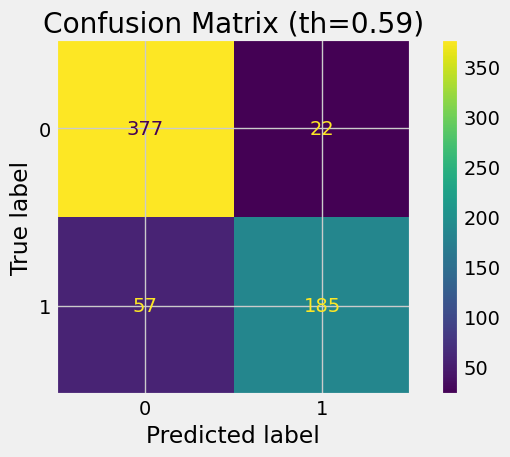

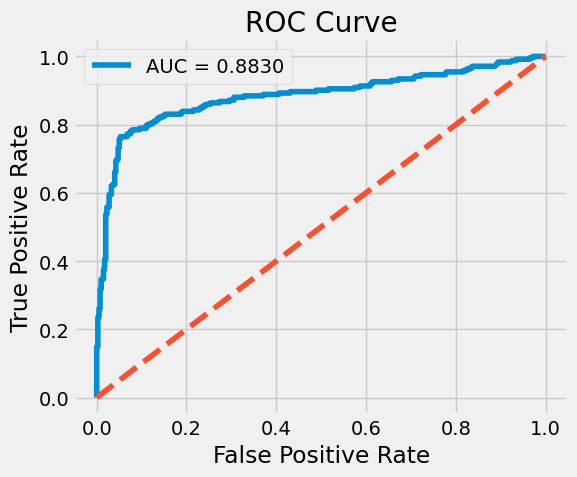

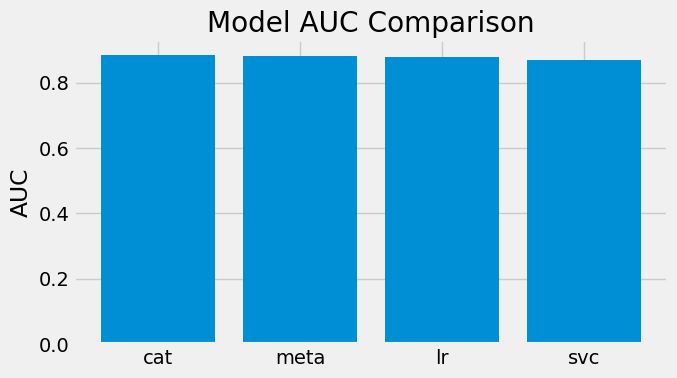


[Model AUC Table]
  model       auc
0   cat  0.885551
3  meta  0.882982
2    lr  0.878353
1   svc  0.870544


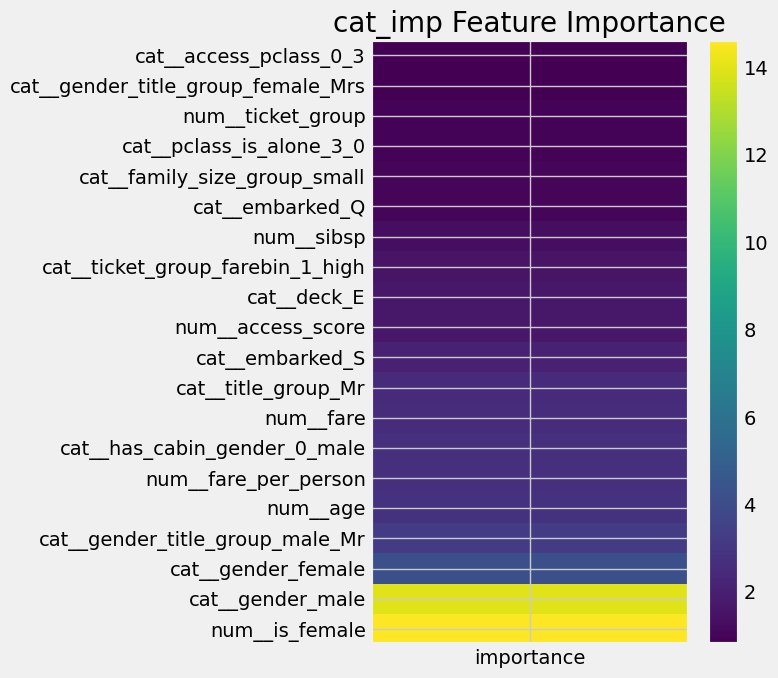

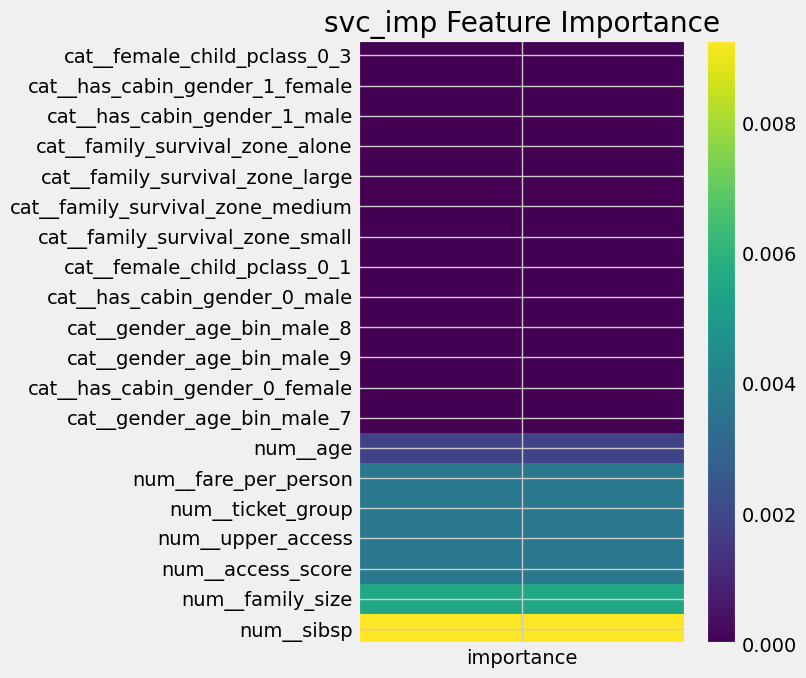

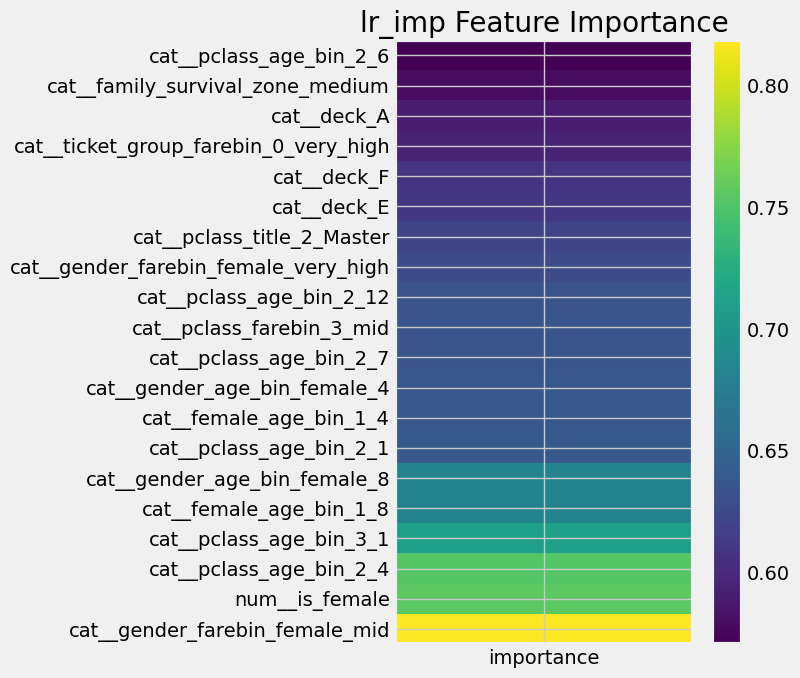


[FP/FN Analysis - meta]
FP count: 22
FN count: 57


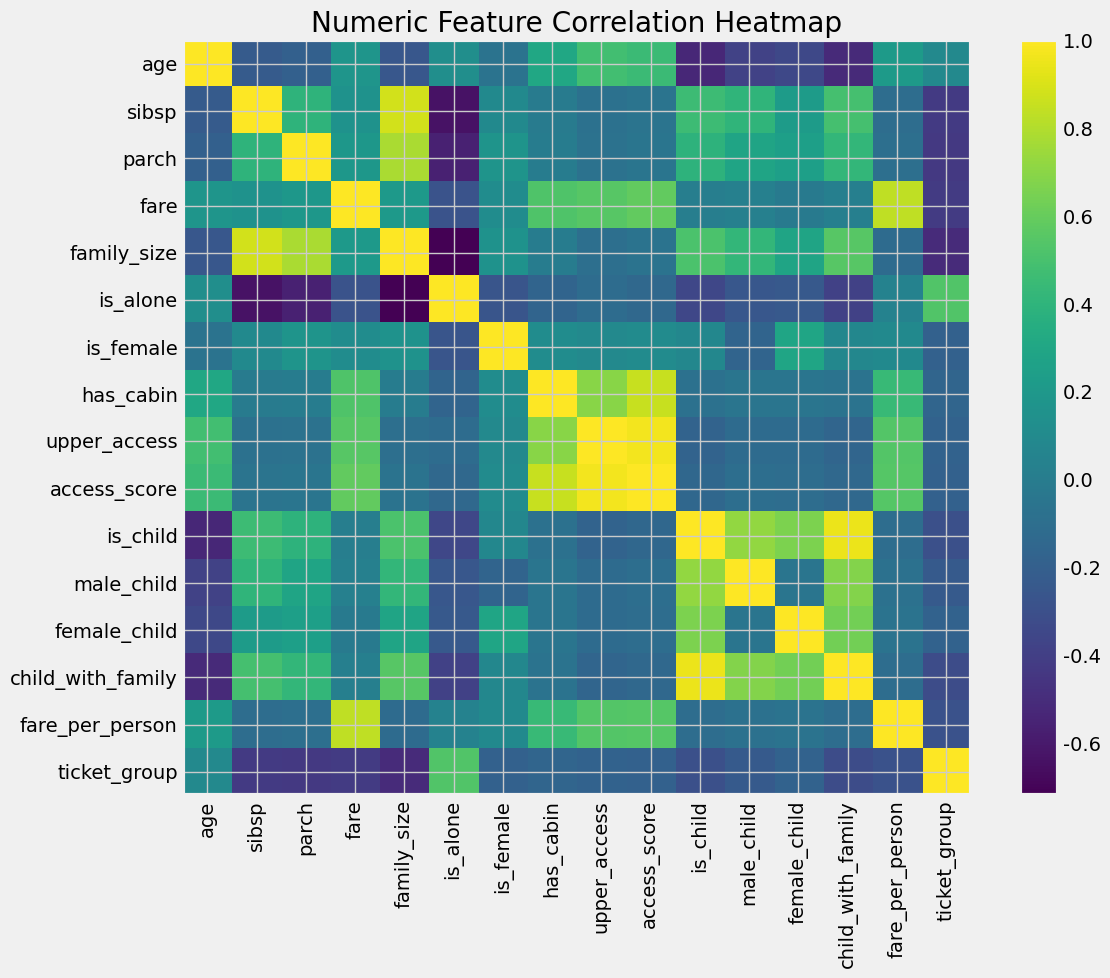

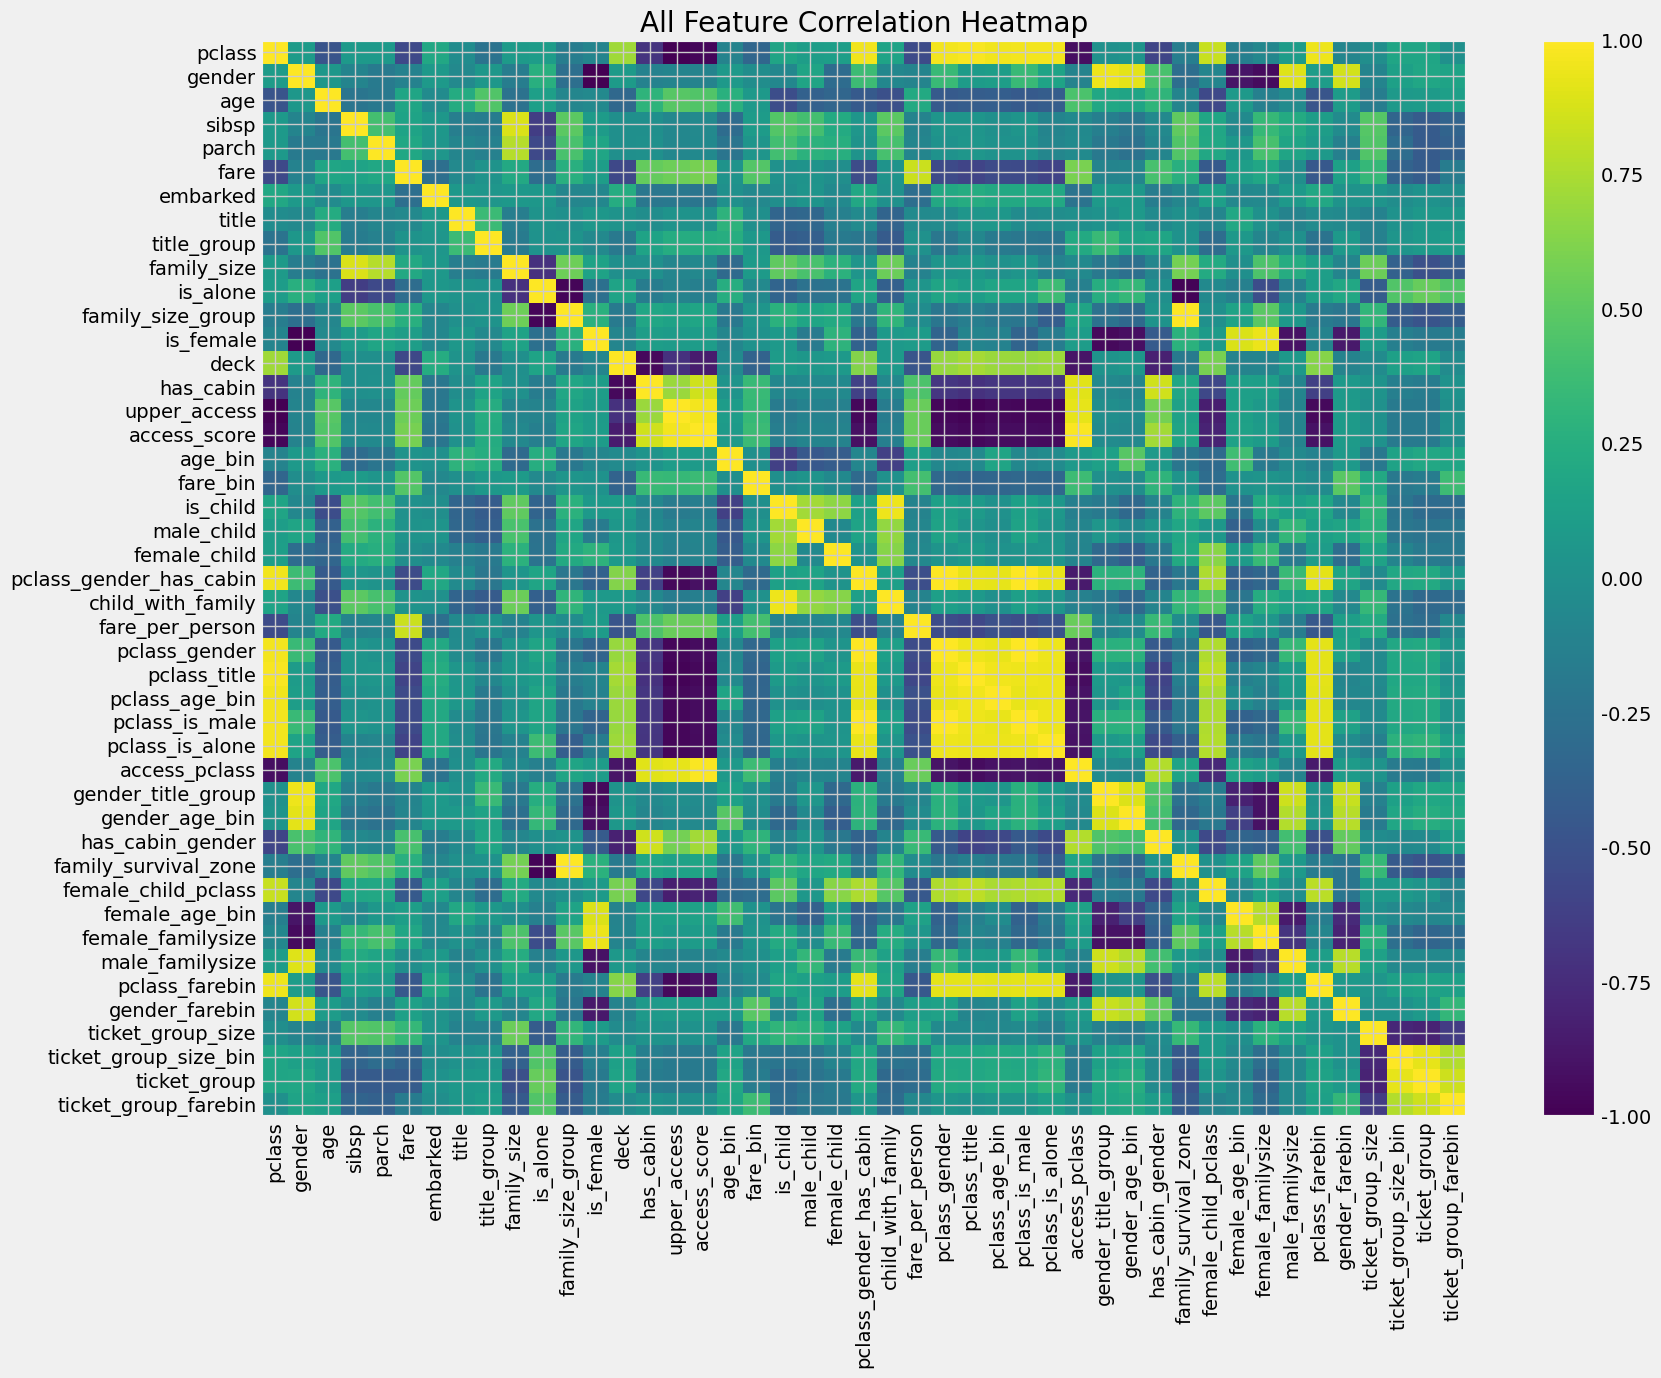

1️⃣ OOF 예측 확률 상관계수
        cat     svc      lr
cat  1.0000  0.9759  0.9713
svc  0.9759  1.0000  0.9540
lr   0.9713  0.9540  1.0000

2️⃣ 예측 확률 통계
     count    mean     std     min     25%     50%     75%     max
cat  641.0  0.3724  0.3761  0.0135  0.0701  0.1359  0.8132  0.9922
svc  641.0  0.3716  0.3529  0.0532  0.1044  0.1249  0.8413  0.9741
lr   641.0  0.3744  0.3885  0.0004  0.0582  0.1357  0.8280  0.9995

3️⃣ 모델 예측 불일치율 (diversity)
  model_a model_b  disagree_rate
1     cat      lr         0.0374
2     svc      lr         0.0359
0     cat     svc         0.0172

4️⃣ 모델 오답 겹침 비율
  model_a model_b  wrong_overlap_rate
0     cat     svc              0.1217
1     cat      lr              0.1154
2     svc      lr              0.1139
submission saved : results_stacking_v1/submission.csv

Best Meta Threshold: 0.59

Meta Eval:
{'threshold': 0.59, 'f1': 0.8240534521158129, 'precision': 0.893719806763285, 'recall': 0.7644628099173554, 'accuracy': 0.8767550702028081, 'auc': np.float64(0.88298

In [ ]:
# train, y_tr, ori_te 가 이미 준비되어 있다고 가정
result_bundle = run_stacking_full_pipeline(
    train_df=train,
    y=y_tr,
    test_df=ori_te,
    save_dir="results_stacking_v1"
)

# 최종 결과 확인
print("\nBest Meta Threshold:", result_bundle["best_meta_threshold"])
print("\nMeta Eval:")
print(result_bundle["meta_eval"])

print("\nFinal Evaluation Table:")
print(result_bundle["final_eval_df"].round(6))